# Comprehensive Model Training: PPO (3 Rewards) + Baselines

Train and compare all models for portfolio rebalancing:

**PPO Models (3 reward types):**
1. PPO with `log_return` reward
2. PPO with `multi_component` reward  
3. PPO with `risk_aware` reward

**Baseline Strategies (5 models):**
4. Equal Weight
5. Buy & Hold
6. Risk Parity
7. Momentum
8. Min Variance

**Key Features:**
- Walk-forward validation (no data leakage)
- 7 tech stocks, weekly rebalancing
- 149 features per asset
- Comprehensive performance comparison
- All hyperparameters from `config.py`

## Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Import config and RL system
from config import *
from rl_system import (
    PortfolioEnv,
    PortfolioMonitor,
    TrainingLogger,
    create_walk_forward_folds,
    print_fold_summary,
    # Baseline strategies
    EqualWeight,
    BuyHold,
    RiskParity,
    Momentum,
    MinVariance,
    backtest_baseline
)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Imports complete")
print(f"✓ Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ Imports complete
✓ Timestamp: 2025-11-18 18:18:50


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Configuration

In [2]:
# Print current configuration
print_config()

# Define all models to train
PPO_REWARD_TYPES = ['log_return', 'multi_component', 'risk_aware']
BASELINE_STRATEGIES = ['equal_weight', 'buy_hold', 'risk_parity', 'momentum', 'min_variance']

print(f"\n📋 Models to Train:")
print(f"   PPO variants: {len(PPO_REWARD_TYPES)} ({', '.join(PPO_REWARD_TYPES)})")
print(f"   Baselines: {len(BASELINE_STRATEGIES)} ({', '.join(BASELINE_STRATEGIES)})")
print(f"   Total models: {len(PPO_REWARD_TYPES) + len(BASELINE_STRATEGIES)}")

CONFIGURATION

📊 DATA
   Data: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/data/processed/train.parquet
   Tickers: 7 - NVDA, MU, AAPL, AMD, ASML, MSFT, GOOG
   Features: 149
   Metadata: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/data/processed/metadata.json

🎯 ENVIRONMENT
   Reward: multi_component (lookback=12)
   Rebalance: 4 weeks
   Transaction cost: 0.0025 (25 bps)
   Max weight: 40%

🔄 VALIDATION
   Folds: 3

🤖 TRAINING
   Timesteps: 50,000
   Learning rate: 0.0003
   Batch size: 64
   Network: [256, 256]

📋 Models to Train:
   PPO variants: 3 (log_return, multi_component, risk_aware)
   Baselines: 5 (equal_weight, buy_hold, risk_parity, momentum, min_variance)
   Total models: 8


## Load Data

In [3]:
# Load training data using config
train_data = load_data()

print(f"\n✓ Loaded {len(train_data):,} samples")
print(f"  Date range: {train_data[DATE_COL].min().date()} to {train_data[DATE_COL].max().date()}")
print(f"  Tickers: {train_data['ticker'].nunique()}")
print(f"  Features: {len(FEATURE_COLS)}")
print(f"  Data size: {train_data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


✓ Loaded 1,708 samples
  Date range: 2020-01-01 to 2024-08-28
  Tickers: 7
  Features: 149
  Data size: 2.11 MB


## Create Walk-Forward Folds

In [4]:
# Create folds using config parameters
folds = create_walk_forward_folds(
    train_data=train_data,
    n_folds=N_FOLDS,
    min_train_size=MIN_TRAIN_SIZE,
    date_col=DATE_COL
)

print_fold_summary(folds)

print(f"\n✓ Created {len(folds)} walk-forward folds")


WALK-FORWARD VALIDATION FOLDS

Fold 0:
  Train: 2020-01-01 to 2020-12-23 (52 periods)
  Val:   2020-12-30 to 2022-03-16 (64 periods)
  Train samples: 364, Val samples: 448

Fold 1:
  Train: 2020-01-01 to 2022-03-16 (116 periods)
  Val:   2022-03-23 to 2023-06-07 (64 periods)
  Train samples: 812, Val samples: 448

Fold 2:
  Train: 2020-01-01 to 2023-06-07 (180 periods)
  Val:   2023-06-14 to 2024-08-28 (64 periods)
  Train samples: 1260, Val samples: 448

✓ Created 3 walk-forward folds


## Part 1: Train PPO Models (3 Reward Types)

Train PPO agents with different reward functions to explore reward shaping.

### PPO Training Function

In [5]:
def train_ppo_fold(fold_idx, train_data, val_data, reward_type, model_name):
    """
    Train PPO agent on one fold with specified reward type.
    
    Parameters:
    -----------
    fold_idx : int
        Fold index
    train_data : pd.DataFrame
        Training data
    val_data : pd.DataFrame
        Validation data
    reward_type : str
        Reward function type ('log_return', 'multi_component', 'risk_aware')
    model_name : str
        Model identifier for saving
        
    Returns:
    --------
    dict : Training results
    """
    print(f"\n{'='*80}")
    print(f"PPO - {reward_type.upper()} | FOLD {fold_idx + 1}/{N_FOLDS}")
    print(f"{'='*80}")
    
    # Verify data
    print(f"\n📊 Data:")
    print(f"   Train: {train_data[DATE_COL].min().date()} to {train_data[DATE_COL].max().date()} "
          f"({len(train_data['date'].unique())} periods)")
    print(f"   Val:   {val_data[DATE_COL].min().date()} to {val_data[DATE_COL].max().date()} "
          f"({len(val_data['date'].unique())} periods)")
    
    assert train_data[DATE_COL].max() < val_data[DATE_COL].min(), "Data leakage!"
    print(f"   ✓ No data leakage")
    
    # Create environments
    def make_env(data, seed_offset=0):
        env = PortfolioEnv(
            data=data.copy(),
            feature_cols=FEATURE_COLS,
            tickers=TICKERS,
            rebalance_frequency=REBALANCE_FREQUENCY,
            transaction_cost=TRANSACTION_COST,
            max_weight_per_asset=MAX_WEIGHT_PER_ASSET,
            reward_lookback=REWARD_LOOKBACK,
            initial_capital=INITIAL_CAPITAL,
            reward_type=reward_type,
            seed=RANDOM_SEED + fold_idx + seed_offset,
            # Risk management parameters
            vol_target=VOL_TARGET,
            min_entropy=MIN_ENTROPY,
            max_turnover=MAX_TURNOVER,
            annualization_factor=ANNUALIZATION_FACTOR
        )
        return PortfolioMonitor(env)
    
    train_env = DummyVecEnv([lambda: make_env(train_data)])
    val_env = DummyVecEnv([lambda: make_env(val_data, seed_offset=1000)])
    
    # Setup output directory
    fold_dir = Path(OUTPUT_DIR) / model_name / f"fold_{fold_idx}"
    fold_dir.mkdir(parents=True, exist_ok=True)
    
    # Create callback
    logger = TrainingLogger(
        eval_env=val_env,
        eval_freq=EVAL_FREQ,
        fold_dir=fold_dir,
        patience=10,
        verbose=VERBOSE
    )
    
    # Create model
    model = PPO(
        "MlpPolicy",
        train_env,
        policy_kwargs=POLICY_KWARGS,
        learning_rate=LEARNING_RATE,
        n_steps=N_STEPS,
        batch_size=BATCH_SIZE,
        n_epochs=N_EPOCHS,
        gamma=GAMMA,
        gae_lambda=GAE_LAMBDA,
        clip_range=CLIP_RANGE,
        ent_coef=ENT_COEF,
        vf_coef=VF_COEF,
        max_grad_norm=MAX_GRAD_NORM,
        verbose=0,
        tensorboard_log=str(fold_dir / "tensorboard") if USE_TENSORBOARD else None
    )
    
    # Train
    print(f"\n🤖 Training for {TOTAL_TIMESTEPS:,} timesteps...\n")
    model.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        callback=logger,
        progress_bar=False
    )
    
    # Save final model
    if SAVE_ALL_MODELS:
        model.save(str(fold_dir / "final_model"))
    
    # Final validation
    print(f"\n📈 Final Validation:")
    obs = val_env.reset()
    done = False
    
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, info = val_env.step(action)
        
        if done[0]:
            stats = info[0].get('portfolio_stats', {})
    
    # Print results
    print(f"   Total Return:    {stats['total_return']*100:>7.2f}%")
    print(f"   Sharpe Ratio:    {stats['sharpe_ratio']:>7.3f}")
    print(f"   Volatility:      {stats['volatility']*100:>7.2f}%")
    print(f"   Max Drawdown:    {stats['max_drawdown']*100:>7.2f}%")
    print(f"   Final Value:     ${stats['portfolio_value']:>,.2f}")
    print(f"   Best Val Sharpe: {logger.best_val_sharpe:>7.3f}")
    
    # Clean up
    train_env.close()
    val_env.close()
    
    # Return results
    return {
        'model_type': 'PPO',
        'model_name': model_name,
        'reward_type': reward_type,
        'fold': fold_idx,
        'total_return': stats['total_return'],
        'sharpe_ratio': stats['sharpe_ratio'],
        'volatility': stats['volatility'],
        'max_drawdown': stats['max_drawdown'],
        'portfolio_value': stats['portfolio_value'],
        'best_val_sharpe': logger.best_val_sharpe,
        'early_stopped': logger.early_stopped,
        'model_path': str(fold_dir / "best_model.zip")
    }

print("✓ PPO training function defined")

✓ PPO training function defined


### Train All PPO Variants

In [6]:
# Train PPO models with all reward types
ppo_results = []

for reward_type in PPO_REWARD_TYPES:
    model_name = f"ppo_{reward_type}"
    print(f"\n\n{'#'*80}")
    print(f"# TRAINING: PPO with {reward_type.upper()} reward")
    print(f"{'#'*80}\n")
    
    for fold_idx, fold in enumerate(folds):
        result = train_ppo_fold(
            fold_idx=fold_idx,
            train_data=fold['train'],
            val_data=fold['val'],
            reward_type=reward_type,
            model_name=model_name
        )
        ppo_results.append(result)

print(f"\n\n{'='*80}")
print("✓ ALL PPO MODELS TRAINED")
print(f"{'='*80}")
print(f"\nTrained {len(ppo_results)} PPO models ({len(PPO_REWARD_TYPES)} reward types × {N_FOLDS} folds)")



################################################################################
# TRAINING: PPO with LOG_RETURN reward
################################################################################


PPO - LOG_RETURN | FOLD 1/3

📊 Data:
   Train: 2020-01-01 to 2020-12-23 (52 periods)
   Val:   2020-12-30 to 2022-03-16 (64 periods)
   ✓ No data leakage

🤖 Training for 50,000 timesteps...

  Train Episode 20: Sharpe=0.744, Return=33.20%
  Train Episode 40: Sharpe=1.276, Return=51.50%

  Validation at step 2500: Sharpe=0.424, Return=17.09%, Drawdown=-27.17%
  → New best model saved (Sharpe: 0.424)
  Train Episode 60: Sharpe=1.719, Return=83.58%
  Train Episode 80: Sharpe=0.723, Return=27.99%

  Validation at step 5000: Sharpe=0.108, Return=4.16%, Drawdown=-28.10%
  → No improvement for 1/10 evaluations
  Train Episode 100: Sharpe=1.075, Return=46.58%
  Train Episode 120: Sharpe=1.458, Return=70.22%
  Train Episode 140: Sharpe=1.428, Return=70.52%

  Validation at step 7500: Sharpe=0.

### PPO Results Summary

In [7]:
# Create PPO results DataFrame
ppo_df = pd.DataFrame(ppo_results)

# Save results
ppo_output_path = Path(OUTPUT_DIR) / 'ppo_all_rewards_results.csv'
ppo_df.to_csv(ppo_output_path, index=False)

# Print summary by reward type
print("\n" + "="*80)
print("PPO RESULTS BY REWARD TYPE")
print("="*80)

for reward_type in PPO_REWARD_TYPES:
    subset = ppo_df[ppo_df['reward_type'] == reward_type]
    print(f"\n{reward_type.upper()}:")
    print(f"   Sharpe Ratio:  {subset['sharpe_ratio'].mean():.3f} ± {subset['sharpe_ratio'].std():.3f}")
    print(f"   Total Return:  {subset['total_return'].mean():.2%} ± {subset['total_return'].std():.2%}")
    print(f"   Volatility:    {subset['volatility'].mean():.2%} ± {subset['volatility'].std():.2%}")
    print(f"   Max Drawdown:  {subset['max_drawdown'].mean():.2%} ± {subset['max_drawdown'].std():.2%}")
    print(f"   Best Sharpe:   {subset['best_val_sharpe'].mean():.3f} ± {subset['best_val_sharpe'].std():.3f}")

print(f"\n💾 Saved to: {ppo_output_path}")

# Display table
ppo_df[['model_name', 'reward_type', 'fold', 'sharpe_ratio', 'total_return', 'volatility', 'max_drawdown']]


PPO RESULTS BY REWARD TYPE

LOG_RETURN:
   Sharpe Ratio:  0.485 ± 0.460
   Total Return:  23.07% ± 22.79%
   Volatility:    38.51% ± 10.47%
   Max Drawdown:  -30.50% ± 14.26%
   Best Sharpe:   1.096 ± 0.272

MULTI_COMPONENT:
   Sharpe Ratio:  0.268 ± 0.044
   Total Return:  12.17% ± 1.33%
   Volatility:    36.17% ± 10.31%
   Max Drawdown:  -31.70% ± 12.11%
   Best Sharpe:   0.670 ± 0.361

RISK_AWARE:
   Sharpe Ratio:  0.164 ± 0.533
   Total Return:  9.29% ± 24.42%
   Volatility:    35.19% ± 6.36%
   Max Drawdown:  -31.78% ± 10.03%
   Best Sharpe:   0.988 ± 0.742

💾 Saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models/ppo_all_rewards_results.csv


,model_name,reward_type,fold,sharpe_ratio,total_return,volatility,max_drawdown
0,ppo_log_return,log_return,0,0.472109,0.200133,0.316408,-0.215290
1,ppo_log_return,log_return,1,0.031455,0.019610,0.505547,-0.469496
2,ppo_log_return,log_return,2,0.950209,0.472321,0.333350,-0.230347
3,ppo_multi_component,multi_component,0,0.302423,0.109893,0.282297,-0.197373
4,ppo_multi_component,multi_component,1,0.218536,0.136121,0.478171,-0.439503
5,ppo_multi_component,multi_component,2,0.283965,0.119129,0.324543,-0.314149
6,ppo_risk_aware,risk_aware,0,0.758422,0.369308,0.339336,-0.263819
7,ppo_risk_aware,risk_aware,1,0.006264,0.003225,0.420878,-0.433517
8,ppo_risk_aware,risk_aware,2,-0.272976,-0.093812,0.295485,-0.256017


## Part 2: Train Baseline Strategies

Train traditional portfolio allocation strategies for comparison.

### Baseline Training Function

In [8]:
def train_baseline_fold(fold_idx, train_data, val_data, strategy_name):
    """
    Run baseline strategy on one fold.
    
    Parameters:
    -----------
    fold_idx : int
        Fold index
    train_data : pd.DataFrame
        Training data (used for lookback calculations)
    val_data : pd.DataFrame
        Validation data
    strategy_name : str
        Baseline strategy name
        
    Returns:
    --------
    dict : Training results
    """
    print(f"\n{'='*80}")
    print(f"BASELINE - {strategy_name.upper()} | FOLD {fold_idx + 1}/{N_FOLDS}")
    print(f"{'='*80}")
    
    # Verify data
    print(f"\n📊 Data:")
    print(f"   Train: {train_data[DATE_COL].min().date()} to {train_data[DATE_COL].max().date()} "
          f"({len(train_data['date'].unique())} periods)")
    print(f"   Val:   {val_data[DATE_COL].min().date()} to {val_data[DATE_COL].max().date()} "
          f"({len(val_data['date'].unique())} periods)")
    
    # Combine train + val for baseline (they can use full history)
    full_data = pd.concat([train_data, val_data], ignore_index=True)
    
    # Create strategy
    if strategy_name == 'equal_weight':
        strategy = EqualWeight(TICKERS, MAX_WEIGHT_PER_ASSET)
    elif strategy_name == 'buy_hold':
        strategy = BuyHold(TICKERS, MAX_WEIGHT_PER_ASSET)
    elif strategy_name == 'risk_parity':
        strategy = RiskParity(TICKERS, MAX_WEIGHT_PER_ASSET, DATE_COL, lookback=12)
    elif strategy_name == 'momentum':
        strategy = Momentum(TICKERS, MAX_WEIGHT_PER_ASSET, DATE_COL, lookback=12)
    elif strategy_name == 'min_variance':
        strategy = MinVariance(TICKERS, MAX_WEIGHT_PER_ASSET, DATE_COL, lookback=12)
    else:
        raise ValueError(f"Unknown strategy: {strategy_name}")
    
    # Backtest on validation data
    print(f"\n🔄 Running backtest...")
    result = backtest_baseline(
        strategy=strategy,
        data=full_data,
        date_col=DATE_COL,
        tickers=TICKERS,
        rebalance_frequency=REBALANCE_FREQUENCY,
        transaction_cost=TRANSACTION_COST,
        initial_capital=INITIAL_CAPITAL,
        annualization_factor=ANNUALIZATION_FACTOR
    )
    
    stats = result['stats']
    
    # Print results
    print(f"\n📈 Validation Results:")
    print(f"   Total Return:  {stats['total_return']*100:>7.2f}%")
    print(f"   Sharpe Ratio:  {stats['sharpe_ratio']:>7.3f}")
    print(f"   Volatility:    {stats['volatility']*100:>7.2f}%")
    print(f"   Max Drawdown:  {stats['max_drawdown']*100:>7.2f}%")
    print(f"   Final Value:   ${stats['portfolio_value']:>,.2f}")
    
    # Return results
    return {
        'model_type': 'Baseline',
        'model_name': strategy_name,
        'reward_type': 'N/A',
        'fold': fold_idx,
        'total_return': stats['total_return'],
        'sharpe_ratio': stats['sharpe_ratio'],
        'volatility': stats['volatility'],
        'max_drawdown': stats['max_drawdown'],
        'portfolio_value': stats['portfolio_value'],
        'best_val_sharpe': stats['sharpe_ratio'],  # Same as sharpe for baselines
        'early_stopped': False,
        'model_path': 'N/A'
    }

print("✓ Baseline training function defined")

✓ Baseline training function defined


### Train All Baseline Strategies

In [9]:
# Train baseline strategies
baseline_results = []

for strategy_name in BASELINE_STRATEGIES:
    print(f"\n\n{'#'*80}")
    print(f"# RUNNING: {strategy_name.upper()} baseline")
    print(f"{'#'*80}\n")
    
    for fold_idx, fold in enumerate(folds):
        result = train_baseline_fold(
            fold_idx=fold_idx,
            train_data=fold['train'],
            val_data=fold['val'],
            strategy_name=strategy_name
        )
        baseline_results.append(result)

print(f"\n\n{'='*80}")
print("✓ ALL BASELINE STRATEGIES EVALUATED")
print(f"{'='*80}")
print(f"\nEvaluated {len(baseline_results)} baselines ({len(BASELINE_STRATEGIES)} strategies × {N_FOLDS} folds)")



################################################################################
# RUNNING: EQUAL_WEIGHT baseline
################################################################################


BASELINE - EQUAL_WEIGHT | FOLD 1/3

📊 Data:
   Train: 2020-01-01 to 2020-12-23 (52 periods)
   Val:   2020-12-30 to 2022-03-16 (64 periods)

🔄 Running backtest...

📈 Validation Results:
   Total Return:   126.55%
   Sharpe Ratio:    1.288
   Volatility:      28.58%
   Max Drawdown:   -25.83%
   Final Value:   $226,552.26

BASELINE - EQUAL_WEIGHT | FOLD 2/3

📊 Data:
   Train: 2020-01-01 to 2022-03-16 (116 periods)
   Val:   2022-03-23 to 2023-06-07 (64 periods)

🔄 Running backtest...

📈 Validation Results:
   Total Return:   144.61%
   Sharpe Ratio:    0.791
   Volatility:      32.76%
   Max Drawdown:   -45.38%
   Final Value:   $244,613.28

BASELINE - EQUAL_WEIGHT | FOLD 3/3

📊 Data:
   Train: 2020-01-01 to 2023-06-07 (180 periods)
   Val:   2023-06-14 to 2024-08-28 (64 periods)

🔄 Running 

### Baseline Results Summary

In [10]:
# Create baseline results DataFrame
baseline_df = pd.DataFrame(baseline_results)

# Save results
baseline_output_path = Path(OUTPUT_DIR) / 'baseline_all_strategies_results.csv'
baseline_df.to_csv(baseline_output_path, index=False)

# Print summary by strategy
print("\n" + "="*80)
print("BASELINE RESULTS BY STRATEGY")
print("="*80)

for strategy_name in BASELINE_STRATEGIES:
    subset = baseline_df[baseline_df['model_name'] == strategy_name]
    print(f"\n{strategy_name.upper()}:")
    print(f"   Sharpe Ratio:  {subset['sharpe_ratio'].mean():.3f} ± {subset['sharpe_ratio'].std():.3f}")
    print(f"   Total Return:  {subset['total_return'].mean():.2%} ± {subset['total_return'].std():.2%}")
    print(f"   Volatility:    {subset['volatility'].mean():.2%} ± {subset['volatility'].std():.2%}")
    print(f"   Max Drawdown:  {subset['max_drawdown'].mean():.2%} ± {subset['max_drawdown'].std():.2%}")

print(f"\n💾 Saved to: {baseline_output_path}")

# Display table
baseline_df[['model_name', 'fold', 'sharpe_ratio', 'total_return', 'volatility', 'max_drawdown']]


BASELINE RESULTS BY STRATEGY

EQUAL_WEIGHT:
   Sharpe Ratio:  0.968 ± 0.278
   Total Return:  167.77% ± 56.48%
   Volatility:    30.81% ± 2.11%
   Max Drawdown:  -38.87% ± 11.29%

BUY_HOLD:
   Sharpe Ratio:  0.955 ± 0.230
   Total Return:  196.19% ± 101.40%
   Volatility:    33.01% ± 2.55%
   Max Drawdown:  -41.08% ± 13.24%

RISK_PARITY:
   Sharpe Ratio:  0.997 ± 0.300
   Total Return:  157.91% ± 44.61%
   Volatility:    29.07% ± 1.72%
   Max Drawdown:  -35.64% ± 8.50%

MOMENTUM:
   Sharpe Ratio:  1.013 ± 0.272
   Total Return:  202.01% ± 84.84%
   Volatility:    32.50% ± 1.76%
   Max Drawdown:  -43.79% ± 15.56%

MIN_VARIANCE:
   Sharpe Ratio:  0.957 ± 0.315
   Total Return:  160.43% ± 44.12%
   Volatility:    30.81% ± 1.85%
   Max Drawdown:  -39.07% ± 11.47%

💾 Saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models/baseline_all_strategies_results.csv


,model_name,fold,sharpe_ratio,total_return,volatility,max_drawdown
0,equal_weight,0,1.288417,1.265523,0.285761,-0.258321
1,equal_weight,1,0.790956,1.446133,0.327616,-0.453817
2,equal_weight,2,0.824398,2.321518,0.310956,-0.453817
3,buy_hold,0,1.211840,1.247392,0.300833,-0.257912
4,buy_hold,1,0.769357,1.515886,0.347401,-0.487274
5,buy_hold,2,0.884274,3.122496,0.342073,-0.487274
6,risk_parity,0,1.342956,1.264601,0.274019,-0.258321
7,risk_parity,1,0.815915,1.383074,0.308322,-0.405461
8,risk_parity,2,0.831308,2.089673,0.289783,-0.405461
9,momentum,0,1.322166,1.458675,0.306325,-0.258321


## Part 3: Comprehensive Model Comparison

Compare all models (PPO + Baselines) across all metrics.

### Combine All Results

In [11]:
# Combine all results
all_results = pd.concat([ppo_df, baseline_df], ignore_index=True)

# Save combined results
all_output_path = Path(OUTPUT_DIR) / 'all_models_results.csv'
all_results.to_csv(all_output_path, index=False)

print(f"✓ Combined results saved to: {all_output_path}")
print(f"\nTotal models evaluated: {len(all_results)} results from {len(PPO_REWARD_TYPES) + len(BASELINE_STRATEGIES)} unique models")

✓ Combined results saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models/all_models_results.csv

Total models evaluated: 24 results from 8 unique models


### Performance Ranking

In [12]:
# Calculate average performance by model
model_summary = all_results.groupby('model_name').agg({
    'sharpe_ratio': ['mean', 'std'],
    'total_return': ['mean', 'std'],
    'volatility': ['mean', 'std'],
    'max_drawdown': ['mean', 'std'],
    'model_type': 'first'
}).round(4)

# Flatten column names
model_summary.columns = ['_'.join(col).strip() for col in model_summary.columns.values]
model_summary = model_summary.reset_index()

# Sort by Sharpe ratio
model_summary = model_summary.sort_values('sharpe_ratio_mean', ascending=False)
model_summary['rank'] = range(1, len(model_summary) + 1)

# Display ranking
print("\n" + "="*100)
print("MODEL PERFORMANCE RANKING (by Sharpe Ratio)")
print("="*100)
print(f"\n{'Rank':<6} {'Model':<25} {'Type':<10} {'Sharpe':<12} {'Return':<12} {'Vol':<12} {'Drawdown':<12}")
print("-" * 100)

for _, row in model_summary.iterrows():
    print(f"{row['rank']:<6} "
          f"{row['model_name']:<25} "
          f"{row['model_type_first']:<10} "
          f"{row['sharpe_ratio_mean']:.3f} ± {row['sharpe_ratio_std']:.3f}  "
          f"{row['total_return_mean']:.1%} ± {row['total_return_std']:.1%}  "
          f"{row['volatility_mean']:.1%} ± {row['volatility_std']:.1%}  "
          f"{row['max_drawdown_mean']:.1%} ± {row['max_drawdown_std']:.1%}")

print("\n" + "="*100)

# Save ranking
ranking_path = Path(OUTPUT_DIR) / 'model_ranking.csv'
model_summary.to_csv(ranking_path, index=False)
print(f"\n💾 Ranking saved to: {ranking_path}")

model_summary


MODEL PERFORMANCE RANKING (by Sharpe Ratio)

Rank   Model                     Type       Sharpe       Return       Vol          Drawdown    
----------------------------------------------------------------------------------------------------
1      momentum                  Baseline   1.013 ± 0.272  202.0% ± 84.8%  32.5% ± 1.8%  -43.8% ± 15.6%
2      risk_parity               Baseline   0.997 ± 0.300  157.9% ± 44.6%  29.1% ± 1.7%  -35.6% ± 8.5%
3      equal_weight              Baseline   0.968 ± 0.278  167.8% ± 56.5%  30.8% ± 2.1%  -38.9% ± 11.3%
4      min_variance              Baseline   0.957 ± 0.315  160.4% ± 44.1%  30.8% ± 1.8%  -39.1% ± 11.5%
5      buy_hold                  Baseline   0.955 ± 0.230  196.2% ± 101.4%  33.0% ± 2.5%  -41.1% ± 13.2%
6      ppo_log_return            PPO        0.485 ± 0.460  23.1% ± 22.8%  38.5% ± 10.5%  -30.5% ± 14.3%
7      ppo_multi_component       PPO        0.268 ± 0.044  12.2% ± 1.3%  36.2% ± 10.3%  -31.7% ± 12.1%
8      ppo_risk_aware         

,model_name,sharpe_ratio_mean,sharpe_ratio_std,total_return_mean,total_return_std,volatility_mean,volatility_std,max_drawdown_mean,max_drawdown_std,model_type_first,rank
3,momentum,1.0129,0.2716,2.0201,0.8484,0.3250,0.0176,-0.4379,0.1556,Baseline,1
7,risk_parity,0.9967,0.2999,1.5791,0.4461,0.2907,0.0172,-0.3564,0.0850,Baseline,2
1,equal_weight,0.9679,0.2781,1.6777,0.5648,0.3081,0.0211,-0.3887,0.1129,Baseline,3
2,min_variance,0.9565,0.3148,1.6043,0.4412,0.3081,0.0185,-0.3907,0.1147,Baseline,4
0,buy_hold,0.9552,0.2296,1.9619,1.0140,0.3301,0.0255,-0.4108,0.1324,Baseline,5
4,ppo_log_return,0.4846,0.4595,0.2307,0.2279,0.3851,0.1047,-0.3050,0.1426,PPO,6
5,ppo_multi_component,0.2683,0.0441,0.1217,0.0133,0.3617,0.1031,-0.3170,0.1211,PPO,7
6,ppo_risk_aware,0.1639,0.5335,0.0929,0.2442,0.3519,0.0636,-0.3178,0.1003,PPO,8


### Statistical Comparison

In [13]:
# Find best model
best_model = model_summary.iloc[0]
print(f"\n🏆 BEST MODEL: {best_model['model_name'].upper()}")
print(f"   Type: {best_model['model_type_first']}")
print(f"   Sharpe Ratio: {best_model['sharpe_ratio_mean']:.3f} ± {best_model['sharpe_ratio_std']:.3f}")
print(f"   Total Return: {best_model['total_return_mean']:.2%} ± {best_model['total_return_std']:.2%}")

# Compare PPO models
print(f"\n📊 PPO REWARD COMPARISON:")
ppo_summary = model_summary[model_summary['model_type_first'] == 'PPO'].sort_values('sharpe_ratio_mean', ascending=False)
for idx, row in ppo_summary.iterrows():
    print(f"   {row['rank']}. {row['model_name']}: Sharpe {row['sharpe_ratio_mean']:.3f}")

# Compare Baseline models  
print(f"\n📊 BASELINE COMPARISON:")
baseline_summary = model_summary[model_summary['model_type_first'] == 'Baseline'].sort_values('sharpe_ratio_mean', ascending=False)
for idx, row in baseline_summary.iterrows():
    print(f"   {row['rank']}. {row['model_name']}: Sharpe {row['sharpe_ratio_mean']:.3f}")


🏆 BEST MODEL: MOMENTUM
   Type: Baseline
   Sharpe Ratio: 1.013 ± 0.272
   Total Return: 202.01% ± 84.84%

📊 PPO REWARD COMPARISON:
   6. ppo_log_return: Sharpe 0.485
   7. ppo_multi_component: Sharpe 0.268
   8. ppo_risk_aware: Sharpe 0.164

📊 BASELINE COMPARISON:
   1. momentum: Sharpe 1.013
   2. risk_parity: Sharpe 0.997
   3. equal_weight: Sharpe 0.968
   4. min_variance: Sharpe 0.957
   5. buy_hold: Sharpe 0.955


## Part 4: Visualizations

Comprehensive visualizations comparing all models.

### Performance Comparison Charts

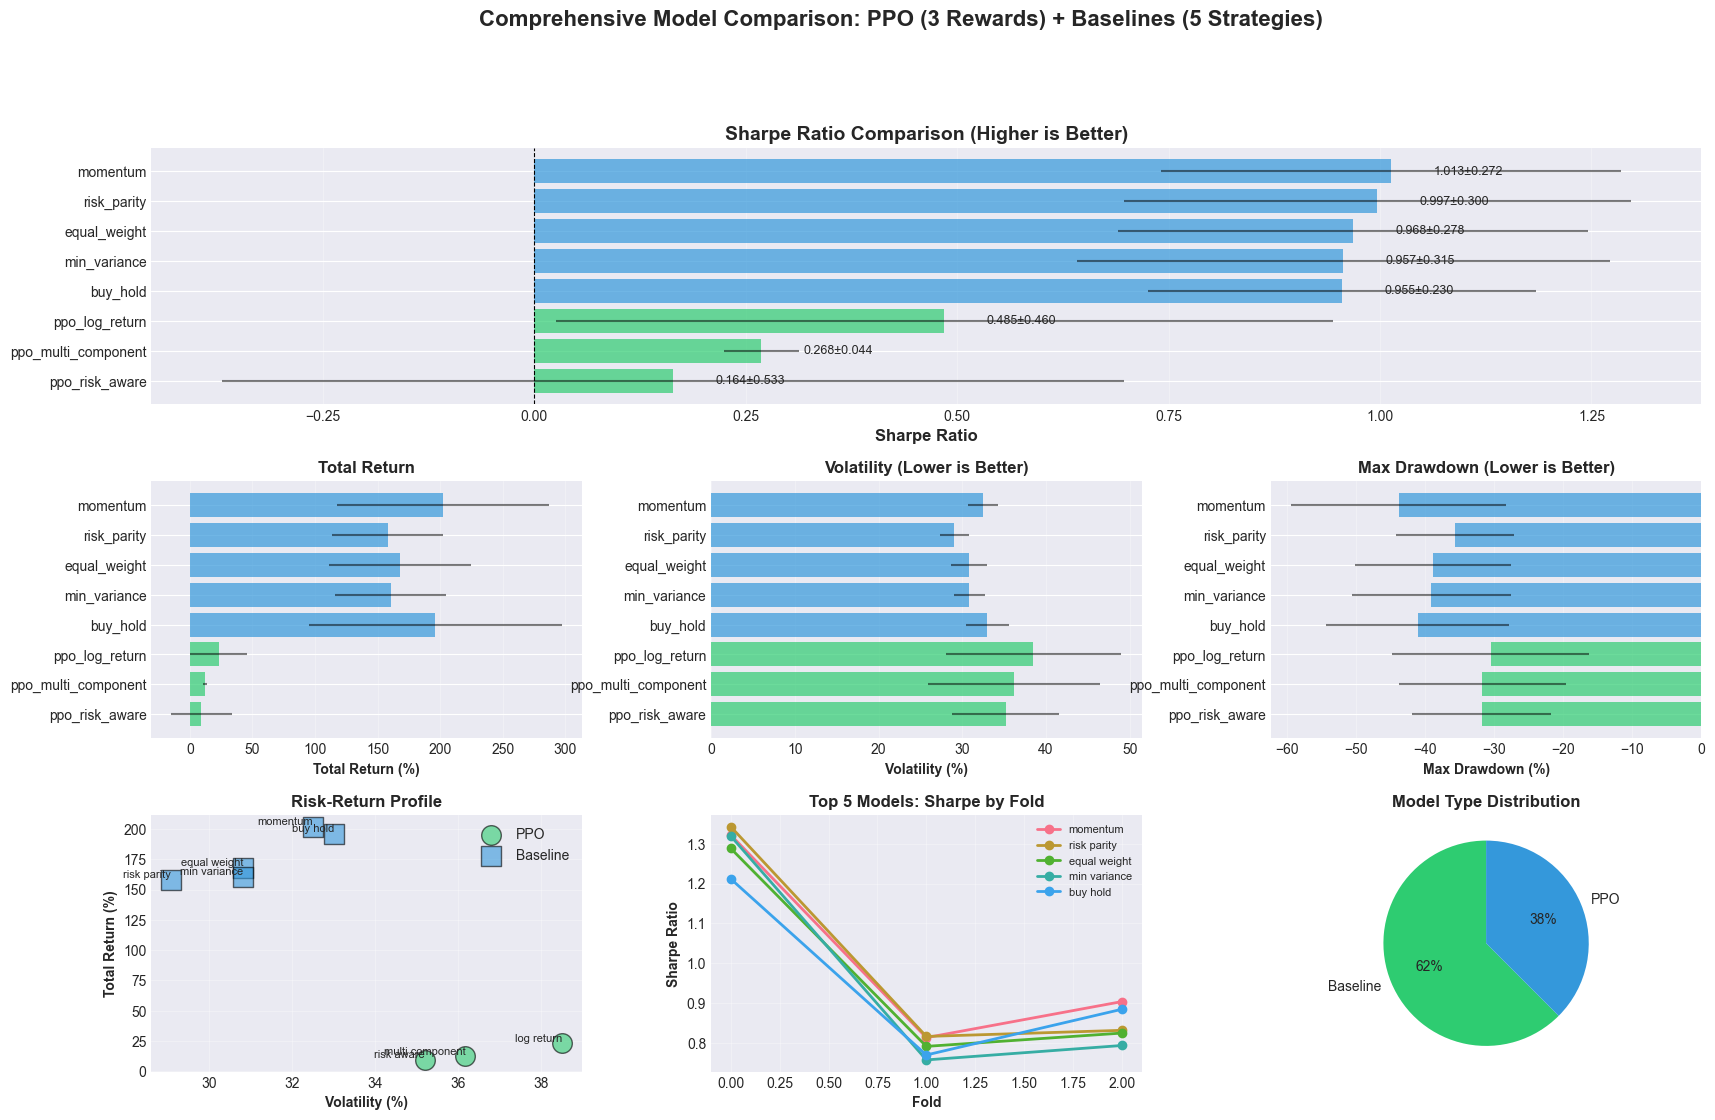


💾 Plot saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models/all_models_comparison.png


In [14]:
# Create comprehensive performance visualization
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Prepare data for plotting
model_summary_plot = model_summary.sort_values('sharpe_ratio_mean', ascending=True)

# 1. Sharpe Ratio Comparison
ax1 = fig.add_subplot(gs[0, :])
colors = ['#2ecc71' if x == 'PPO' else '#3498db' for x in model_summary_plot['model_type_first']]
bars = ax1.barh(model_summary_plot['model_name'], model_summary_plot['sharpe_ratio_mean'], 
                color=colors, alpha=0.7)
ax1.errorbar(model_summary_plot['sharpe_ratio_mean'], model_summary_plot['model_name'],
             xerr=model_summary_plot['sharpe_ratio_std'], fmt='none', color='black', alpha=0.5)
ax1.set_xlabel('Sharpe Ratio', fontsize=12, fontweight='bold')
ax1.set_title('Sharpe Ratio Comparison (Higher is Better)', fontsize=14, fontweight='bold')
ax1.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (val, std) in enumerate(zip(model_summary_plot['sharpe_ratio_mean'], 
                                    model_summary_plot['sharpe_ratio_std'])):
    ax1.text(val + 0.05, i, f'{val:.3f}±{std:.3f}', 
             va='center', fontsize=9)

# 2. Total Return Comparison
ax2 = fig.add_subplot(gs[1, 0])
ax2.barh(model_summary_plot['model_name'], model_summary_plot['total_return_mean']*100, 
         color=colors, alpha=0.7)
ax2.errorbar(model_summary_plot['total_return_mean']*100, model_summary_plot['model_name'],
             xerr=model_summary_plot['total_return_std']*100, fmt='none', color='black', alpha=0.5)
ax2.set_xlabel('Total Return (%)', fontsize=10, fontweight='bold')
ax2.set_title('Total Return', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# 3. Volatility Comparison
ax3 = fig.add_subplot(gs[1, 1])
ax3.barh(model_summary_plot['model_name'], model_summary_plot['volatility_mean']*100, 
         color=colors, alpha=0.7)
ax3.errorbar(model_summary_plot['volatility_mean']*100, model_summary_plot['model_name'],
             xerr=model_summary_plot['volatility_std']*100, fmt='none', color='black', alpha=0.5)
ax3.set_xlabel('Volatility (%)', fontsize=10, fontweight='bold')
ax3.set_title('Volatility (Lower is Better)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

# 4. Max Drawdown Comparison
ax4 = fig.add_subplot(gs[1, 2])
ax4.barh(model_summary_plot['model_name'], model_summary_plot['max_drawdown_mean']*100, 
         color=colors, alpha=0.7)
ax4.errorbar(model_summary_plot['max_drawdown_mean']*100, model_summary_plot['model_name'],
             xerr=model_summary_plot['max_drawdown_std']*100, fmt='none', color='black', alpha=0.5)
ax4.set_xlabel('Max Drawdown (%)', fontsize=10, fontweight='bold')
ax4.set_title('Max Drawdown (Lower is Better)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

# 5. Risk-Return Scatter
ax5 = fig.add_subplot(gs[2, 0])
for model_type, color, marker in [('PPO', '#2ecc71', 'o'), ('Baseline', '#3498db', 's')]:
    mask = model_summary['model_type_first'] == model_type
    ax5.scatter(model_summary[mask]['volatility_mean']*100, 
                model_summary[mask]['total_return_mean']*100,
                c=color, s=200, alpha=0.6, marker=marker, label=model_type, edgecolors='black')
    
    # Add labels
    for _, row in model_summary[mask].iterrows():
        ax5.annotate(row['model_name'].replace('_', ' ').replace('ppo ', ''), 
                     (row['volatility_mean']*100, row['total_return_mean']*100),
                     fontsize=8, ha='right', va='bottom')

ax5.set_xlabel('Volatility (%)', fontsize=10, fontweight='bold')
ax5.set_ylabel('Total Return (%)', fontsize=10, fontweight='bold')
ax5.set_title('Risk-Return Profile', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Sharpe by Fold
ax6 = fig.add_subplot(gs[2, 1])
for model_name in model_summary.head(5)['model_name']:
    data = all_results[all_results['model_name'] == model_name]
    ax6.plot(data['fold'], data['sharpe_ratio'], marker='o', label=model_name.replace('_', ' '), linewidth=2)
ax6.set_xlabel('Fold', fontsize=10, fontweight='bold')
ax6.set_ylabel('Sharpe Ratio', fontsize=10, fontweight='bold')
ax6.set_title('Top 5 Models: Sharpe by Fold', fontsize=12, fontweight='bold')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

# 7. Model Type Distribution
ax7 = fig.add_subplot(gs[2, 2])
model_counts = model_summary['model_type_first'].value_counts()
ax7.pie(model_counts.values, labels=model_counts.index, autopct='%1.0f%%', 
        colors=['#2ecc71', '#3498db'], startangle=90)
ax7.set_title('Model Type Distribution', fontsize=12, fontweight='bold')

plt.suptitle('Comprehensive Model Comparison: PPO (3 Rewards) + Baselines (5 Strategies)', 
             fontsize=16, fontweight='bold', y=0.995)

# Save plot
plot_path = Path(OUTPUT_DIR) / 'all_models_comparison.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💾 Plot saved to: {plot_path}")

### Detailed PPO Reward Comparison

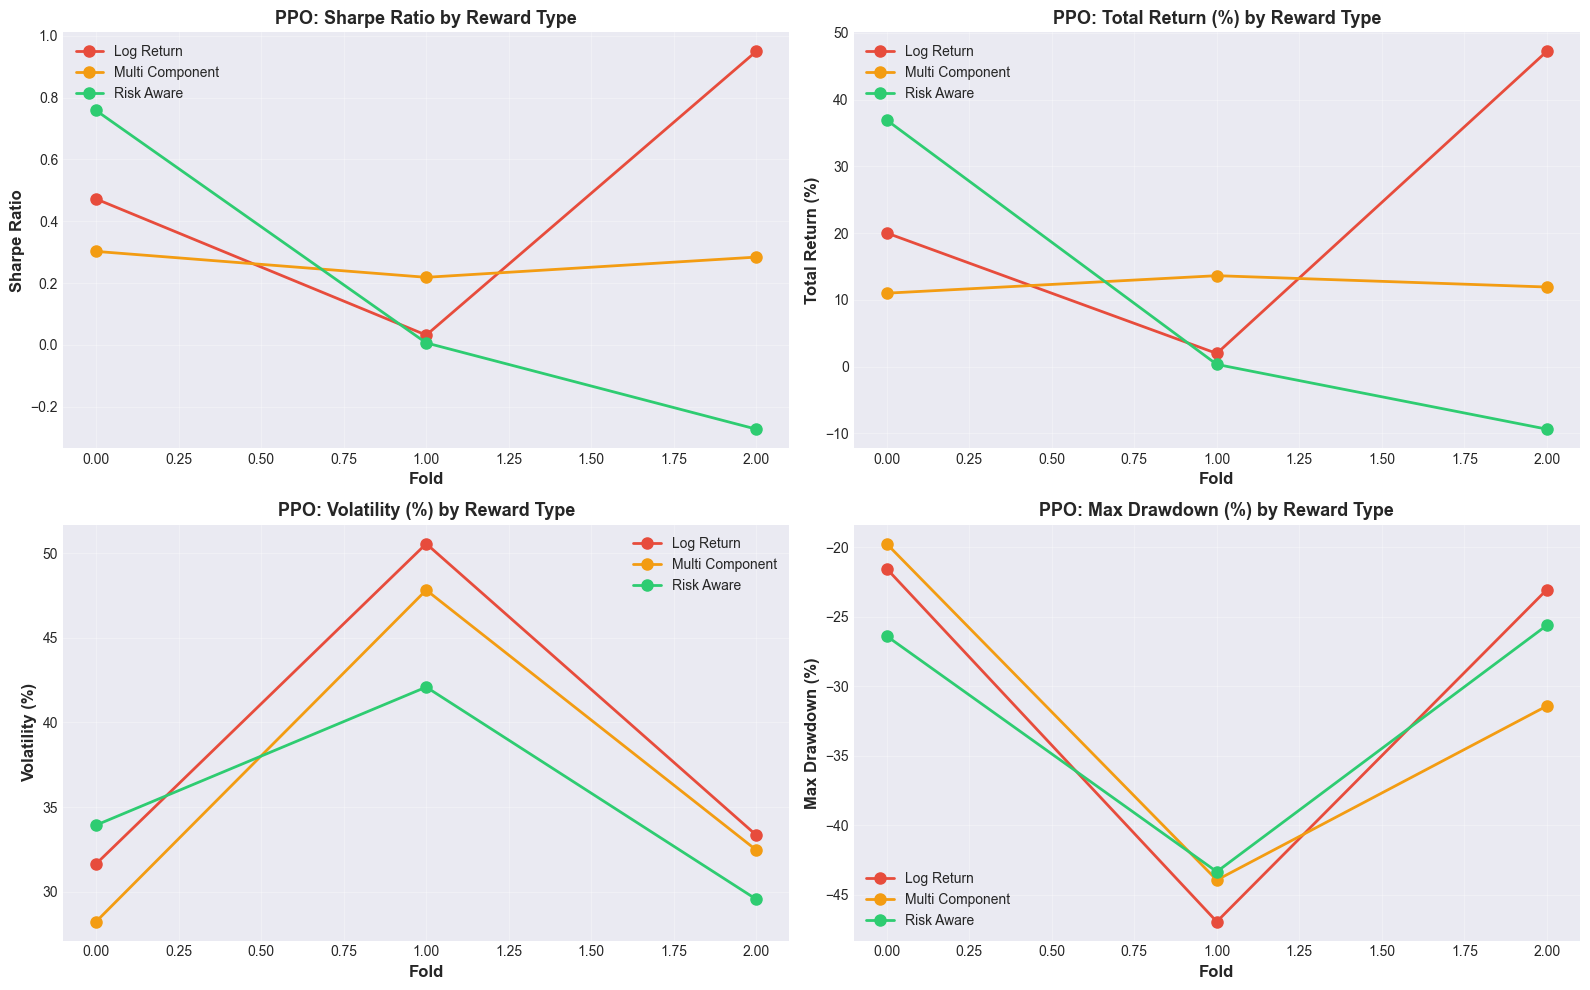


💾 PPO comparison saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models/ppo_reward_comparison.png


In [15]:
# Compare PPO reward types in detail
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics = ['sharpe_ratio', 'total_return', 'volatility', 'max_drawdown']
titles = ['Sharpe Ratio', 'Total Return (%)', 'Volatility (%)', 'Max Drawdown (%)']
colors_map = {'log_return': '#e74c3c', 'multi_component': '#f39c12', 'risk_aware': '#2ecc71'}

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    
    for reward_type in PPO_REWARD_TYPES:
        data = ppo_df[ppo_df['reward_type'] == reward_type]
        values = data[metric].values
        if metric in ['total_return', 'volatility', 'max_drawdown']:
            values = values * 100
        
        ax.plot(data['fold'], values, marker='o', linewidth=2, markersize=8,
                label=reward_type.replace('_', ' ').title(), 
                color=colors_map[reward_type])
    
    ax.set_xlabel('Fold', fontsize=12, fontweight='bold')
    ax.set_ylabel(title, fontsize=12, fontweight='bold')
    ax.set_title(f'PPO: {title} by Reward Type', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save plot
ppo_plot_path = Path(OUTPUT_DIR) / 'ppo_reward_comparison.png'
plt.savefig(ppo_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💾 PPO comparison saved to: {ppo_plot_path}")

### Heatmap: Model × Metric

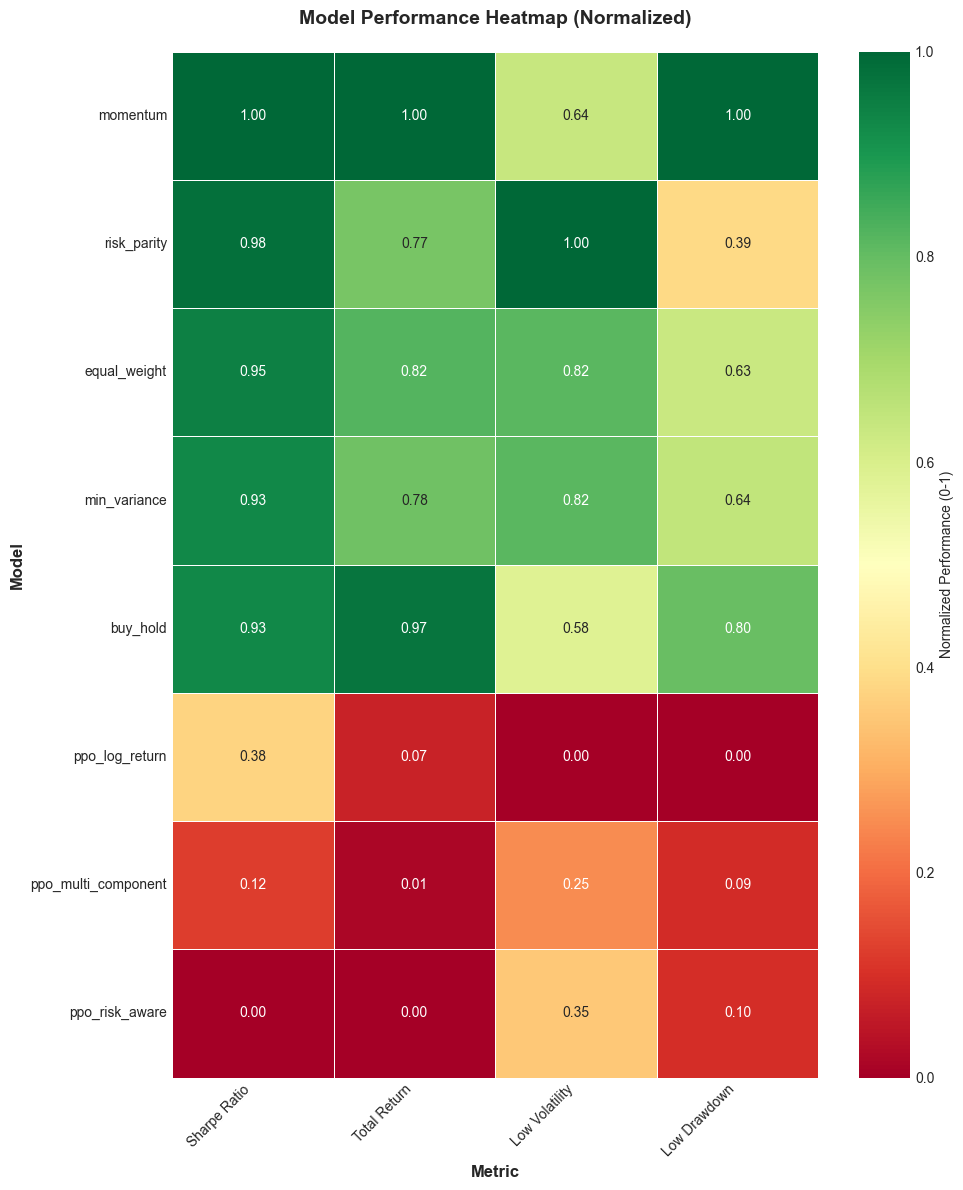


💾 Heatmap saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models/performance_heatmap.png


In [16]:
# Create heatmap of normalized performance
pivot_data = model_summary.copy()
pivot_data = pivot_data[['model_name', 'sharpe_ratio_mean', 'total_return_mean', 
                          'volatility_mean', 'max_drawdown_mean']].set_index('model_name')

# Normalize metrics (higher is better for all)
pivot_data_norm = pivot_data.copy()
pivot_data_norm['sharpe_ratio_mean'] = (pivot_data['sharpe_ratio_mean'] - pivot_data['sharpe_ratio_mean'].min()) / \
                                        (pivot_data['sharpe_ratio_mean'].max() - pivot_data['sharpe_ratio_mean'].min())
pivot_data_norm['total_return_mean'] = (pivot_data['total_return_mean'] - pivot_data['total_return_mean'].min()) / \
                                        (pivot_data['total_return_mean'].max() - pivot_data['total_return_mean'].min())
# Invert volatility and drawdown (lower is better)
pivot_data_norm['volatility_mean'] = 1 - ((pivot_data['volatility_mean'] - pivot_data['volatility_mean'].min()) / \
                                           (pivot_data['volatility_mean'].max() - pivot_data['volatility_mean'].min()))
pivot_data_norm['max_drawdown_mean'] = 1 - ((pivot_data['max_drawdown_mean'] - pivot_data['max_drawdown_mean'].min()) / \
                                             (pivot_data['max_drawdown_mean'].max() - pivot_data['max_drawdown_mean'].min()))

# Rename columns for display
pivot_data_norm.columns = ['Sharpe Ratio', 'Total Return', 'Low Volatility', 'Low Drawdown']

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(pivot_data_norm, annot=True, fmt='.2f', cmap='RdYlGn', center=0.5,
            linewidths=0.5, cbar_kws={'label': 'Normalized Performance (0-1)'},
            ax=ax, vmin=0, vmax=1)
ax.set_title('Model Performance Heatmap (Normalized)', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Model', fontsize=12, fontweight='bold')
ax.set_xlabel('Metric', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save heatmap
heatmap_path = Path(OUTPUT_DIR) / 'performance_heatmap.png'
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💾 Heatmap saved to: {heatmap_path}")

## Summary & Recommendations

In [17]:
print("\n" + "="*100)
print("FINAL SUMMARY & RECOMMENDATIONS")
print("="*100)

# Best overall model
best_overall = model_summary.iloc[0]
print(f"\n🏆 BEST OVERALL MODEL: {best_overall['model_name'].upper()}")
print(f"   Type: {best_overall['model_type_first']}")
print(f"   Average Sharpe: {best_overall['sharpe_ratio_mean']:.3f} ± {best_overall['sharpe_ratio_std']:.3f}")
print(f"   Average Return: {best_overall['total_return_mean']:.2%} ± {best_overall['total_return_std']:.2%}")
print(f"   Average Volatility: {best_overall['volatility_mean']:.2%} ± {best_overall['volatility_std']:.2%}")
print(f"   Average Max DD: {best_overall['max_drawdown_mean']:.2%} ± {best_overall['max_drawdown_std']:.2%}")

# Best PPO model
best_ppo = ppo_summary.iloc[0]
print(f"\n🤖 BEST PPO MODEL: {best_ppo['model_name'].upper()}")
print(f"   Average Sharpe: {best_ppo['sharpe_ratio_mean']:.3f} ± {best_ppo['sharpe_ratio_std']:.3f}")
print(f"   Rank: #{best_ppo['rank']} overall")

# Best Baseline
best_baseline = baseline_summary.iloc[0]
print(f"\n📊 BEST BASELINE: {best_baseline['model_name'].upper()}")
print(f"   Average Sharpe: {best_baseline['sharpe_ratio_mean']:.3f} ± {best_baseline['sharpe_ratio_std']:.3f}")
print(f"   Rank: #{best_baseline['rank']} overall")

# PPO vs Baseline comparison
ppo_wins = sum(ppo_summary['rank'] < best_baseline['rank'])
print(f"\n📈 PPO vs BASELINES:")
print(f"   {ppo_wins}/{len(PPO_REWARD_TYPES)} PPO models beat the best baseline")
if ppo_wins == len(PPO_REWARD_TYPES):
    print(f"   ✅ All PPO models outperform baselines!")
elif ppo_wins > 0:
    print(f"   ⚠️  Some PPO models beat baselines, but not all")
else:
    print(f"   ❌ Baselines outperform all PPO models")

# Recommendations
print(f"\n💡 RECOMMENDATIONS:")
print(f"   1. Production Model: {best_overall['model_name']}")
if best_overall['model_type_first'] == 'PPO':
    print(f"   2. Reward Type: {best_ppo['model_name'].replace('ppo_', '')} works best")
print(f"   3. Consider ensemble of top-3 models for robustness")
print(f"   4. Monitor performance across all {N_FOLDS} folds for stability")

# Save summary report
summary_path = Path(OUTPUT_DIR) / 'training_summary.txt'
with open(summary_path, 'w') as f:
    f.write("COMPREHENSIVE MODEL TRAINING SUMMARY\n")
    f.write("="*100 + "\n\n")
    f.write(f"Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Total Models Trained: {len(PPO_REWARD_TYPES) + len(BASELINE_STRATEGIES)}\n")
    f.write(f"Total Results: {len(all_results)}\n")
    f.write(f"Walk-Forward Folds: {N_FOLDS}\n\n")
    f.write(f"Best Model: {best_overall['model_name']}\n")
    f.write(f"Best Sharpe: {best_overall['sharpe_ratio_mean']:.3f}\n")
    f.write(f"Best Return: {best_overall['total_return_mean']:.2%}\n")

print(f"\n💾 Summary saved to: {summary_path}")
print("\n" + "="*100)
print("✅ TRAINING COMPLETE!")
print("="*100)


FINAL SUMMARY & RECOMMENDATIONS

🏆 BEST OVERALL MODEL: MOMENTUM
   Type: Baseline
   Average Sharpe: 1.013 ± 0.272
   Average Return: 202.01% ± 84.84%
   Average Volatility: 32.50% ± 1.76%
   Average Max DD: -43.79% ± 15.56%

🤖 BEST PPO MODEL: PPO_LOG_RETURN
   Average Sharpe: 0.485 ± 0.460
   Rank: #6 overall

📊 BEST BASELINE: MOMENTUM
   Average Sharpe: 1.013 ± 0.272
   Rank: #1 overall

📈 PPO vs BASELINES:
   0/3 PPO models beat the best baseline
   ❌ Baselines outperform all PPO models

💡 RECOMMENDATIONS:
   1. Production Model: momentum
   3. Consider ensemble of top-3 models for robustness
   4. Monitor performance across all 3 folds for stability

💾 Summary saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models/training_summary.txt

✅ TRAINING COMPLETE!


## Notes

**Models Trained:**
- 3 PPO variants (log_return, multi_component, risk_aware)
- 5 Baseline strategies (equal_weight, buy_hold, risk_parity, momentum, min_variance)

**Output Files:**
- `models/ppo_all_rewards_results.csv` - PPO results
- `models/baseline_all_strategies_results.csv` - Baseline results
- `models/all_models_results.csv` - Combined results
- `models/model_ranking.csv` - Performance ranking
- `models/all_models_comparison.png` - Main visualization
- `models/ppo_reward_comparison.png` - PPO comparison
- `models/performance_heatmap.png` - Normalized heatmap
- `models/training_summary.txt` - Text summary

**Best Models:**
- Saved in respective fold directories
- PPO models: `models/ppo_{reward_type}/fold_{i}/best_model.zip`
- Test on hold-out data in next notebook